In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND7_nterms2/load_band7_nterms2_data.py"

path = band7_nterms2_data_folder_path

B7 = BuildBandDictionary(
    path,
    StokesI_wcs,
    xmin,
    xmax,
    ymin,
    ymax,
    reference_length_pix,
    reference_length_AU,
    BMAJ_pix,
    BMIN_pix,
    BPA_deg_cartesian,
    max_length_pix,
    reference_fraction,
    POLI_debiased_mJy,
    StokesI_mJy, StokesI_stretched_mJy_grid, StokesI_unstretched_cbar_ticks_grid,
    RA_centre_pix, Dec_centre_pix,
    POLF_debiased
    
)

band = Band 7 nterms2
max_str = 'J163135.750-240128.700'
StokesI_wcs CRPIX = [513. 513.]
StokesI_wcs CDELT = [-5.e-06  5.e-06]
Pixel scale = 0.018 arcsec/pixel
Dec_max_pix = 581
 


In [4]:
print(B7['StokesI_stretched_mJy_grid'].dtype)
print(B7['StokesI_stretched_mJy_grid'].shape)

float32
(1024, 1024)


In [5]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND5/load_band5_data.py"

path = band5_data_folder_path

B5 = BuildBandDictionary(
    path,
    StokesI_wcs,
    xmin,
    xmax,
    ymin,
    ymax,
    reference_length_pix,
    reference_length_AU,
    BMAJ_pix,
    BMIN_pix,
    BPA_deg_cartesian,
    max_length_pix,
    reference_fraction,
    POLI_debiased_mJy, # There is no Band 5 debiased yet,
    StokesI_mJy, StokesI_stretched_mJy_grid, StokesI_unstretched_cbar_ticks_grid,
    RA_centre_pix, Dec_centre_pix,
    POLF_debiased
)

stream_vectors_B5 = stream_vectors

band = Band 5
max_str = 'J163135.750-240128.700'
StokesI_wcs CRPIX = [513. 513.]
StokesI_wcs CDELT = [-5.e-06  5.e-06]
Pixel scale = 0.018 arcsec/pixel
Dec_max_pix = 581
 


In [6]:
print(B5['StokesI_stretched_mJy_grid'].dtype)
print(B5['StokesI_stretched_mJy_grid'].shape)

float32
(1024, 1024)


In [13]:
def MakeGalaxyContaminationPlot_stretch(B5, B7,
                                fig_x_size = 15, 
                                fig_y_size = 6.5,
                                axis_num_fs = constants.axis_num_fs,
                                cbar_fs = constants.cbar_fs,
                                cmap = "afmhot",
                                fontcolor = 'white',
                                reference_lw = 3,
                                beam_lw = 2,
                                spline_lw = 1,
                                label = 'wavelength'):
    
    # StokeI_wcs will be the same for boht B5 and B7
    #StokesI_wcs = B5_plotting['StokesI_wcs']
    
    text_sf = 0.75
    
    # Make the plots
#     fig, axes = plt.subplots(1, 2, figsize=(fig_x_size, fig_y_size),
#                        gridspec_kw={'wspace': -0.5},  # Increase wspace for more horizontal space
#                        subplot_kw={'projection': StokesI_wcs},
#                       sharey = True)
    
    fig = plt.figure(figsize=(fig_x_size, fig_y_size))
    gs = fig.add_gridspec(1, 2, wspace=-0.02)
    
    
    bands = [B5, B7]
    bands_num = [5, 7]
    
    centre_strings = [constants.centre_str_band5, constants.centre_str_band7_nterms2]
    
    axes = []
    
    for i, b in enumerate(bands):
        
        
        
        # Convert do delta RA and delta Dec
        # ------------------------------------------------------------------
        # Get the centre position of the disk
        centre_string = centre_strings[i]

        ra_part = centre_string[1:11]
        dec_part = centre_string[11:]


        ra_string = (
        ra_part[:2] + 'h' +
        ra_part[2:4] + 'm' +
        ra_part[4:] + 's'
        )

        dec_string = (
            dec_part[:3] + 'd' +
            dec_part[3:5] + 'm' +
            dec_part[5:] + 's'
        )


        centre = SkyCoord(
            ra_string,
            dec_string,
            frame='icrs'
        )
        
        
        ax = fig.add_subplot(gs[0, i], projection=b['StokesI_wcs'])
        axes.append(ax)
        
        offset_frame = SkyOffsetFrame(origin=centre)

        overlay = ax.get_coords_overlay(offset_frame)
        # ------------------------------------------------------------------
        
        
        # Set xmin, xmax, ymin, ymax
        # ---------------------------------------------
        half_size_pix = 7.5 / 0.018

        xmin = b['RA_centre_pix'] - half_size_pix
        xmax = b['RA_centre_pix'] + half_size_pix
        ymin = b['Dec_centre_pix'] - half_size_pix
        ymax = b['Dec_centre_pix'] + half_size_pix
        
        # Set the x and y lims
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        # ---------------------------------------------
            
            
        
        # ---------------------------------------------------------
        # Convert midpoint from data coords -> axes coords
        
        # Scalebar line
        line_x_pos = xmax - 0.04 * (xmax - xmin) - 100
        line_y_pos = ymin - 0.14 * (ymin - ymax) - 25
        
        x0 = line_x_pos - b['reference_length_pix']
        x1 = line_x_pos
        
        x_mid_data = (x0 + x1) / 2
        y_mid_data = line_y_pos

        display_coords = ax.transData.transform((x_mid_data, y_mid_data))
        axes_coords = ax.transAxes.inverted().transform(display_coords)

        x_axes, y_axes = axes_coords
        # ---------------------------------------------------------
        
        
#         ax = axes[i]

        # Set what we are plotting
        #im = ax.imshow(b['StokesI_stretched_mJy_grid'], cmap = cmap)
        im = ax.imshow(b['StokesI_mJy'], cmap = cmap)
    
    
        # Colourbar
        # ---------------------------------------------------------
        cax = inset_axes(
            ax,
            width="100%",
            height="6%",
            loc="upper center",
            bbox_to_anchor=(0, 0.075, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0
        )

        # Add colorbar
        cbar = plt.colorbar(im, cax=cax, orientation="horizontal")

        # Put ticks on top
        cbar.ax.xaxis.set_ticks_position("top")

        # Format colorbar
        cbar.ax.tick_params(
            labelsize=writeup_grid_axis_num_fs,
            which="major",
            length=7,
            direction="in",
        )
        
#         cbar.set_ticks(constants.normalized_cbar_ticks_grid)
#         cbar.set_ticklabels([f"{val:.2f}" for val in (b['StokesI_unstretched_cbar_ticks_grid'])])
        
#         if i == 1:
#             ticks = [(x, y) for x, y in zip(constants.normalized_cbar_ticks_grid, b['StokesI_unstretched_cbar_ticks_grid']) if y != 0.02]
#             cbar.set_ticks([x for x, y in ticks])
#             cbar.set_ticklabels([f"{y:.2f}" for x, y in ticks])
        # ---------------------------------------------------------
        
    
        # Remove axis labels
        ax.set_xlabel(' ', fontsize = 0)
        ax.set_ylabel(' ', fontsize = 0)
        
        

            
        # Add line and text for 100 AU 
        # ------------------------------------------------------------------
#         add_reference_scale_bar(ax, 
#                                 xmin, xmax, ymin, ymax,
#                                 b['reference_length_pix'],
#                                 b['reference_length_AU'],
#                                 writeup_grid_axis_label_fs, fontcolor, reference_lw)
        
        shift = 0.10
        ax.plot([x0, x1], [line_y_pos, line_y_pos], color='black', linewidth=2.5)
        print(rf'x0 = {x0} and x1 = {x1}]')
        ax.text(
                x_axes ,
                y_axes + 0.015,
                f"{b['reference_length_AU']} au",
                transform=ax.transAxes,
                fontsize=writeup_grid_axis_label_fs,
                ha='center',
                va='bottom'
            )
        # ------------------------------------------------------------------
        
        # Add the beam
        # ------------------------------------------------------------------
        beam_x_pos = xmin - 0.1 * (xmin - xmax)
        beam_y_pos = ymin - 0.1 * (ymin - ymax)
        
        beam = Ellipse((beam_x_pos, beam_y_pos), 
               width = b['BMAJ_pix'], height = b['BMIN_pix'],  
               angle = b['BPA_deg_cartesian'], 
               edgecolor= fontcolor, 
               facecolor='none', 
               alpha=1, 
               lw=beam_lw)

        ax.add_patch(beam)
        # ------------------------------------------------------------------
    


        # Formatting axes
        # ------------------------------------------------------------------
        #add_min_major_ticks_wcs(ax)
        # ------------------------------------------------------------------
        # Make the axes thicker
        #ax.coords.frame.set_linewidth(spline_lw)

        #ax.tick_params(axis="both", which="major", width=spline_lw)
        # ------------------------------------------------------------------


        # Add the band labels
        # ------------------------------------------------------------------
        add_band_label(ax, bands_num[i], label, constants, label_fs = text_fs, fontcolor = fontcolor)
        # ------------------------------------------------------------------
        
        
        for j in (0, 1):
            ax.coords[j].set_ticks_visible(False)
            ax.coords[j].set_ticklabel_visible(False)

            overlay[j].set_ticks_position('b' if j == 0 else 'l')
            overlay[j].set_ticklabel_position('b' if j == 0 else 'l')
            overlay[j].set_format_unit(u.arcsec)
            overlay[j].set_axislabel(' ')
            overlay[j].set_ticks(spacing= 5* u.arcsec, direction='in')
            overlay[j].set_ticklabel(size=writeup_grid_axis_num_fs)

            if i != 0 and j == 1:
                overlay[j].set_ticks_visible(False)
                overlay[j].set_ticklabel_visible(False)

        ax.coords[0].set_ticklabel_visible(False)

    
    fig.text(
        0.5,
        1.1,
        r'Stokes I [mJy beam$^{-1}$]',
        ha='center',
        va='top',
        fontsize= constants.writeup_grid_axis_label_fs
    )

    fig.supxlabel(
        r"$\Delta$ RA [arcsec]",
        fontsize=constants.writeup_grid_axis_label_fs,
        y=-0.015
    )

    fig.supylabel(
        r"$\Delta$ Dec [arcsec]",
        fontsize=constants.writeup_grid_axis_label_fs,
        x=0.075
    )
    
        
    return fig, axes

x0 = 756.2458307802906 and x1 = 798.3333333333334]
x0 = 756.2458307802906 and x1 = 798.3333333333334]


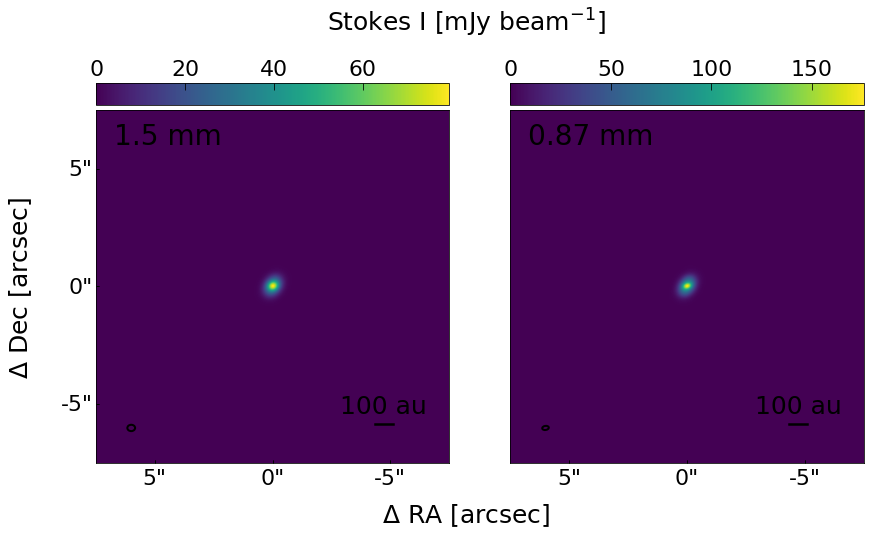

In [16]:
fig, ax = MakeGalaxyContaminationPlot_stretch(B5, B7, 
                                              cmap = 'viridis', 
                                              #cmap = 'bone_r', 
                                              fontcolor = 'black')


# plt.savefig(writeup_image_folder_path + '/GalaxyContamination/'+ "StokesI_BothBands.png", 
#             dpi=300,
#             bbox_inches='tight')   